In [1]:
import sys
from pathlib import Path

from runner.runners import ZSSRRunner
from data.preprocessing import ZSSRPreprocessing
from data.datasets import Urban100Dataset
from data.utils import estimate_michaeli_irani_kernel
from eval.pipeline import SRPipeline
from eval.utils import generate_comparison_plots, plot_layer_distributions
from model.zssr_model import ZSSRConvNet

import matplotlib.pyplot as plt
import torch

import config

In [2]:
NUM_PATCHES = 64
BATCH_SIZE = 1
SCALE_FACTOR = 4
N_SCALE_FACTORS = 3
N_EPOCHS = 20

Ablation study: sigmoid after res-conn vs sigmoid inside res-conn vs no sigmoid, bicubic vs learnt kernel for a total of 6 variants.

In [ ]:
SIGMOID_MODES = ['none']
# UPSAMPLE_MODES = ['learnt', 'bicubic']
UPSAMPLE_MODES = ['learnt']

for sigmoid_mode in SIGMOID_MODES:
    for upsample_mode in UPSAMPLE_MODES:
        print(f"Running ZSSR with sigmoid_mode={sigmoid_mode} and upsample_mode={upsample_mode}...")
        
        model = ZSSRConvNet(sigmoid_mode=sigmoid_mode, upsample_mode=upsample_mode)
        runner = ZSSRRunner(model=model)
        pipeline = SRPipeline(
            runner=runner,
            dataset_zip_path=config.URBAN100_ZIP,
            datasets_dir=config.DATASET_DIR,
            output_dir=config.ZSSR_OUTPUT_DIR / f"variance-aware-sigmoid-{sigmoid_mode}" / config.URBAN100_NAME,
            scale_factor=SCALE_FACTOR
        )
        
        pipeline.run()

Running ZSSR with sigmoid_mode=after and upsample_mode=learnt...
Found 100 LR images. Starting Evaluation Loop...

--- Evaluating: img_092_SRF_4_LR.png ---


Estimating ZSSR kernel using Michaeli-Irani method...
Training ZSSR locally on img_092_SRF_4_LR.png...
--- Training ZSSR for 50 epochs ---
--- Training ZSSR with s_i=1.5 ---
End of epoch 0, Loss: 0.220417
End of epoch 1, Loss: 0.197646
End of epoch 2, Loss: 0.191172
End of epoch 3, Loss: 0.191027
End of epoch 4, Loss: 0.182148
End of epoch 5, Loss: 0.184997
End of epoch 6, Loss: 0.180463
End of epoch 7, Loss: 0.177877
End of epoch 8, Loss: 0.179740
End of epoch 9, Loss: 0.177186
End of epoch 10, Loss: 0.177181
End of epoch 11, Loss: 0.170705
End of epoch 12, Loss: 0.161973
End of epoch 13, Loss: 0.170132
End of epoch 14, Loss: 0.181585
End of epoch 15, Loss: 0.174307
End of epoch 16, Loss: 0.158875
End of epoch 17, Loss: 0.151798
End of epoch 18, Loss: 0.155562
End of epoch 19, Loss: 0.131292
End of epoch 20, Loss: 0.145600
End of epoch 21, Loss: 0.171133
End of epoch 22, Loss: 0.156760
End of epoch 23, Loss: 0.133690
End of epoch 24, Loss: 0.126667
End of epoch 25, Loss: 0.144584
End 

In [ ]:
SIGMOID_MODES = ['none']
# UPSAMPLE_MODES = ['learnt', 'bicubic']
UPSAMPLE_MODES = ['bicubic']

for sigmoid_mode in SIGMOID_MODES:
    for upsample_mode in UPSAMPLE_MODES:
        print(f"Running ZSSR with sigmoid_mode={sigmoid_mode} and upsample_mode={upsample_mode}...")
        
        model = ZSSRConvNet(sigmoid_mode=sigmoid_mode, upsample_mode=upsample_mode)
        runner = ZSSRRunner(model=model)
        pipeline = SRPipeline(
            runner=runner,
            dataset_zip_path=config.BSD100_ZIP,
            datasets_dir=config.DATASET_DIR,
            output_dir=config.ZSSR_OUTPUT_DIR / f"variance-aware-sigmoid-{sigmoid_mode}" / config.BSD100_NAME,
            scale_factor=SCALE_FACTOR
        )
        
        pipeline.run()

Running ZSSR with sigmoid_mode=after and upsample_mode=learnt...
Found 100 LR images. Starting Evaluation Loop...

--- Evaluating: 227092.png ---
Estimating ZSSR kernel using Michaeli-Irani method...
Training ZSSR locally on 227092.png...
--- Training ZSSR for 50 epochs ---
--- Training ZSSR with s_i=1.5 ---
End of epoch 0, Loss: 0.139546
End of epoch 1, Loss: 0.169562
End of epoch 2, Loss: 0.111191
End of epoch 3, Loss: 0.122817
End of epoch 4, Loss: 0.119530
End of epoch 5, Loss: 0.106255
End of epoch 6, Loss: 0.109390
End of epoch 7, Loss: 0.100550
End of epoch 8, Loss: 0.103684
End of epoch 9, Loss: 0.101162
End of epoch 10, Loss: 0.100179
End of epoch 11, Loss: 0.099483
End of epoch 12, Loss: 0.098008
End of epoch 13, Loss: 0.096090
End of epoch 14, Loss: 0.093285
End of epoch 15, Loss: 0.102547
End of epoch 16, Loss: 0.092038
End of epoch 17, Loss: 0.094334
End of epoch 18, Loss: 0.088665
End of epoch 19, Loss: 0.081628
End of epoch 20, Loss: 0.078716
End of epoch 21, Loss: 0.092

KeyboardInterrupt: 

In [ ]:
"""
strategy = ZSSRPreprocessing(num_patches=64) 
dataset = Urban100Dataset(root_dir=str('datasets/temp/jfk/'), scale_factor=SCALE_FACTOR, strategy=strategy)
runner = ZSSRRunner(model=ZSSRConvNet(sigmoid_mode='none', upsample_mode='learnt'))
lr_tensor = strategy.base_img.unsqueeze(0).to(runner.device)
estimated_kernel = estimate_michaeli_irani_kernel(lr_tensor, scale_factor=SCALE_FACTOR)
strategy.set_kernel(estimated_kernel.cpu())
out_size = (int(strategy.base_img.shape[1] * SCALE_FACTOR), int(strategy.base_img.shape[2] * SCALE_FACTOR))
runner.train(dataset, out_size, n_epochs=10)
"""

--- Training ZSSR for 10 epochs ---
--- Training ZSSR with s_i=1.5 ---
End of epoch 0, Loss: 0.093027
End of epoch 1, Loss: 0.087230
End of epoch 2, Loss: 0.086223
End of epoch 3, Loss: 0.082096
End of epoch 4, Loss: 0.082301
End of epoch 5, Loss: 0.083617
End of epoch 6, Loss: 0.079215
End of epoch 7, Loss: 0.082201
End of epoch 8, Loss: 0.083726
End of epoch 9, Loss: 0.081040
--- Training ZSSR with s_i=2.0 ---
End of epoch 0, Loss: 0.078695
End of epoch 1, Loss: 0.078217
End of epoch 2, Loss: 0.074996
End of epoch 3, Loss: 0.072482
End of epoch 4, Loss: 0.071054
End of epoch 5, Loss: 0.073393
End of epoch 6, Loss: 0.071901
End of epoch 7, Loss: 0.065329
End of epoch 8, Loss: 0.069296
End of epoch 9, Loss: 0.068323
--- Training ZSSR with s_i=2.5 ---
End of epoch 0, Loss: 0.066300
End of epoch 1, Loss: 0.063005
End of epoch 2, Loss: 0.065816
End of epoch 3, Loss: 0.064341
End of epoch 4, Loss: 0.066439
End of epoch 5, Loss: 0.063210
End of epoch 6, Loss: 0.067585
End of epoch 7, Loss: 

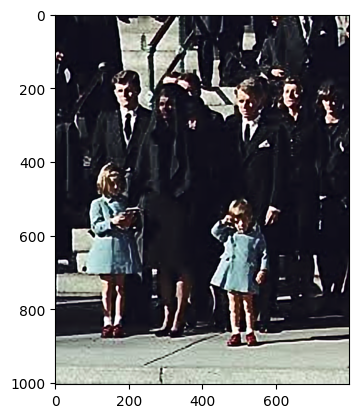

In [ ]:
"""
out_size = (int(strategy.base_img.shape[1] * SCALE_FACTOR), int(strategy.base_img.shape[2] * SCALE_FACTOR))
out = runner.model(runner.test_img.to(runner.device), out_size).cpu().squeeze(0)
plt.imshow(out.permute(1, 2, 0).detach().clamp(0, 1))
"""

Visualization of Weights and Gradient update

In [11]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

max_epochs = len(runner.layer_stats['weights']) - 1
slider = widgets.IntSlider(min=0, max=max_epochs, step=1, value=0, description='Epoch:')
out = widgets.Output()

def update_plot(change=None): 
    epoch = slider.value 
    
    with out:
        clear_output(wait=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        
        # Plot Weight Histogram
        weights = runner.layer_stats['weights'][epoch]
        ax1.hist(weights, bins=50, color='royalblue', alpha=0.7)
        ax1.set_title(f'Weight Distribution (Epoch {epoch})')
        ax1.set_xlabel('Weight Value')
        ax1.grid(axis='y', alpha=0.3)
        
        # Plot Gradient Histogram
        grads = runner.layer_stats['gradients'][epoch]
        ax2.hist(grads, bins=50, color='darkorange', alpha=0.7)
        ax2.set_title(f'Gradient Distribution (Epoch {epoch})')
        ax2.set_xlabel('Gradient Value')
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

slider.observe(update_plot, names='value')

display(slider, out)

update_plot()

IntSlider(value=0, description='Epoch:', max=599)

Output()

Metrics

Skipping BSD100 - learnt-kernel-sigmoid-inside due to error: list index out of range
Skipping BSD100 - learnt-kernel-sigmoid-none due to error: list index out of range
Skipping Urban100 - learnt-kernel-sigmoid-inside due to error: No columns to parse from file
Skipping Urban100 - learnt-kernel-sigmoid-none due to error: list index out of range


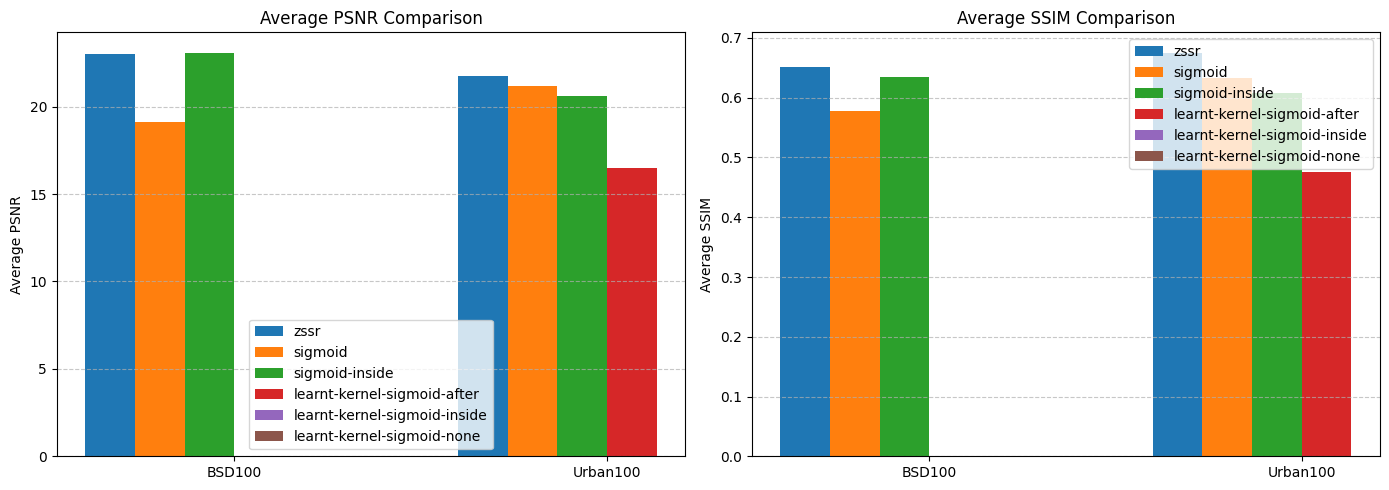

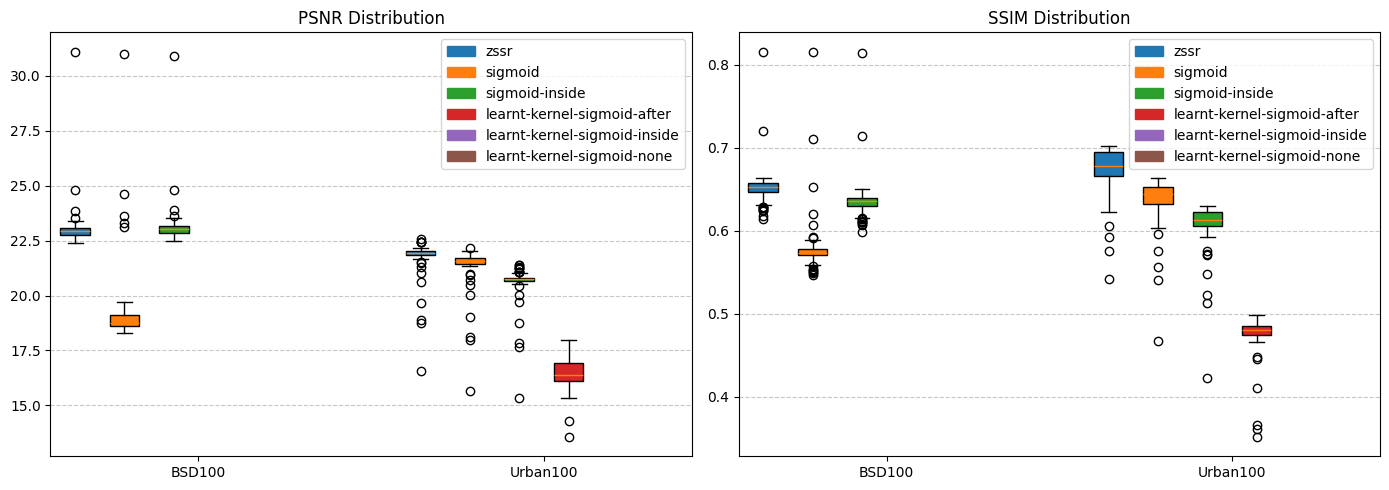

In [ ]:
datasets = (config.BSD100_NAME, config.URBAN100_NAME)

configurations = (
    "zssr",
    "sigmoid",
    "sigmoid-inside",
    "variance-aware-sigmoid-none"
)

folder_dict = {
    dataset: {
        cfg: (config.ZSSR_OUTPUT_DIR / dataset) if cfg == "zssr" else (config.ZSSR_OUTPUT_DIR / cfg / dataset)
        for cfg in configurations
    }
    for dataset in datasets
}

generate_comparison_plots(folder_dict)